# Credit Risk Default Prediction — Innovexa Catalyst Case Study

**Role:** Machine Learning Engineer, Innovexa Catalyst
**Objective:** Predict the probability that a loan applicant defaults, build models that generalize well and are robust to class imbalance, interpret the model, and produce actionable credit-risk recommendations.

---

**Target variable:** `loan_status` (1 = default, 0 = non-default)


In [1]:
# =============================================================================
# 0. ENVIRONMENT SETUP
# =============================================================================
# Run this cell first. It installs every package used later in the notebook.
# If you are in an environment where these are already installed, this is a no-op.

import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib seaborn \
    xgboost lightgbm catboost imbalanced-learn shap optuna plotly joblib



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# 0.1 IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    precision_recall_curve, auc, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## 6.1 Data Understanding & EDA

We load the dataset, inspect structure, check for missing values, duplicates and inconsistencies, then analyze univariate, bivariate and multivariate patterns, the target distribution, and risk factors associated with default.


In [4]:
# -----------------------------------------------------------------------
# Load data
# -----------------------------------------------------------------------
df_raw = pd.read_csv("credit_risk_dataset.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# -----------------------------------------------------------------------
# Missing values
# -----------------------------------------------------------------------
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df


,missing_count,missing_pct
loan_int_rate,3116,9.56
person_emp_length,895,2.75


In [7]:
# -----------------------------------------------------------------------
# Duplicates
# -----------------------------------------------------------------------
n_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes/len(df_raw)*100:.2f}% of data)")


Exact duplicate rows: 165 (0.51% of data)


In [8]:
# -----------------------------------------------------------------------
# Inconsistencies / implausible values
# -----------------------------------------------------------------------
print("person_age range:", df_raw['person_age'].min(), "-", df_raw['person_age'].max())
print("Top 5 oldest ages:\n", df_raw['person_age'].sort_values(ascending=False).head())
print()
print("person_emp_length range:", df_raw['person_emp_length'].min(), "-", df_raw['person_emp_length'].max())
print("Top 5 longest emp_length:\n", df_raw['person_emp_length'].sort_values(ascending=False).head())
print()
implausible = df_raw[df_raw['person_emp_length'] > (df_raw['person_age'] - 16)]
print(f"Rows where employment length exceeds plausible working years given age: {len(implausible)}")


person_age range: 20 - 144
Top 5 oldest ages:
 81       144
183      144
32297    144
575      123
747      123
Name: person_age, dtype: int64

person_emp_length range: 0.0 - 123.0
Top 5 longest emp_length:
 210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
Name: person_emp_length, dtype: float64

Rows where employment length exceeds plausible working years given age: 740


In [9]:
# -----------------------------------------------------------------------
# Categorical value counts (sanity check for typos / inconsistent labels)
# -----------------------------------------------------------------------
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for c in cat_cols:
    print(f"--- {c} ---")
    print(df_raw[c].value_counts())
    print()


--- person_home_ownership ---
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent ---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade ---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file ---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64



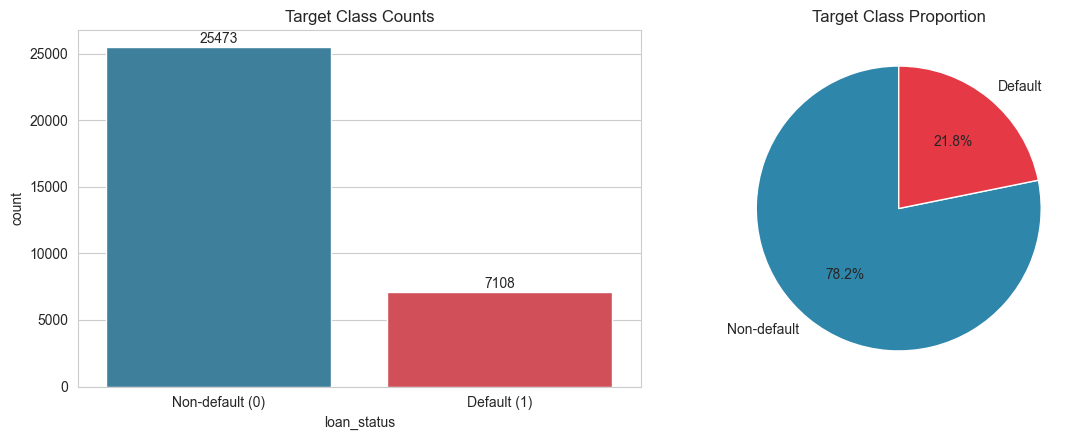

Default rate: 21.82%  ->  Class imbalance ratio approx 1:3.6


In [10]:
# -----------------------------------------------------------------------
# Target distribution
# -----------------------------------------------------------------------
target_counts = df_raw['loan_status'].value_counts()
target_pct = df_raw['loan_status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x='loan_status', data=df_raw, ax=axes[0], hue='loan_status', palette=['#2E86AB', '#E63946'], legend=False)
axes[0].set_title("Target Class Counts")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-default (0)', 'Default (1)'])
for i, v in enumerate(target_counts.sort_index().values):
    axes[0].text(i, v + 300, str(v), ha='center')

axes[1].pie(target_pct.sort_index(), labels=['Non-default', 'Default'], autopct='%1.1f%%',
            colors=['#2E86AB', '#E63946'], startangle=90)
axes[1].set_title("Target Class Proportion")
plt.tight_layout()
plt.show()

print(f"Default rate: {target_pct[1]:.2f}%  ->  Class imbalance ratio approx 1:{target_counts[0]/target_counts[1]:.1f}")


**Observation:** The target is imbalanced (~22% default, ~78% non-default), roughly a 1:3.6 ratio. This confirms the brief's note that the target distribution is highly imbalanced, and means we must use imbalance-aware techniques (class weights / SMOTE) and imbalance-robust metrics (AUC-ROC, PR-AUC, F1, KS) rather than relying on accuracy.

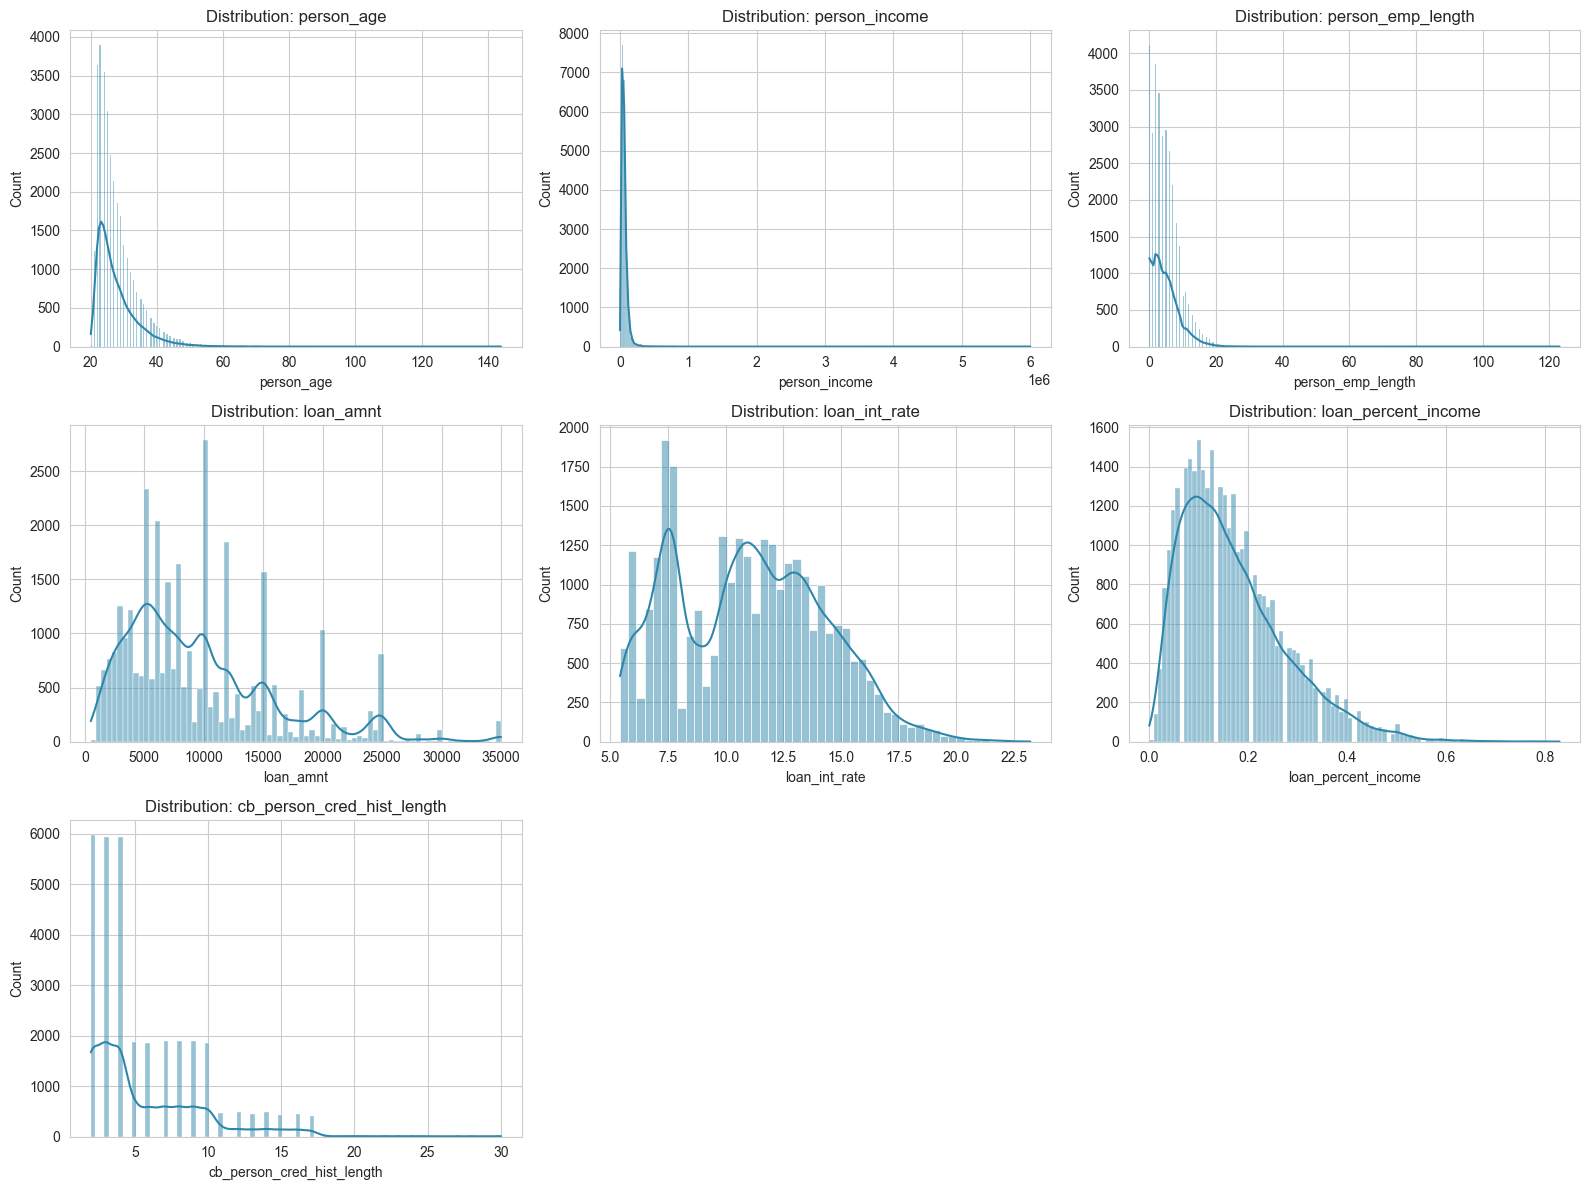

In [11]:
# -----------------------------------------------------------------------
# Univariate analysis: numeric features
# -----------------------------------------------------------------------
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_raw[col].dropna(), kde=True, ax=axes[i], color='#2E86AB')
    axes[i].set_title(f"Distribution: {col}")
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


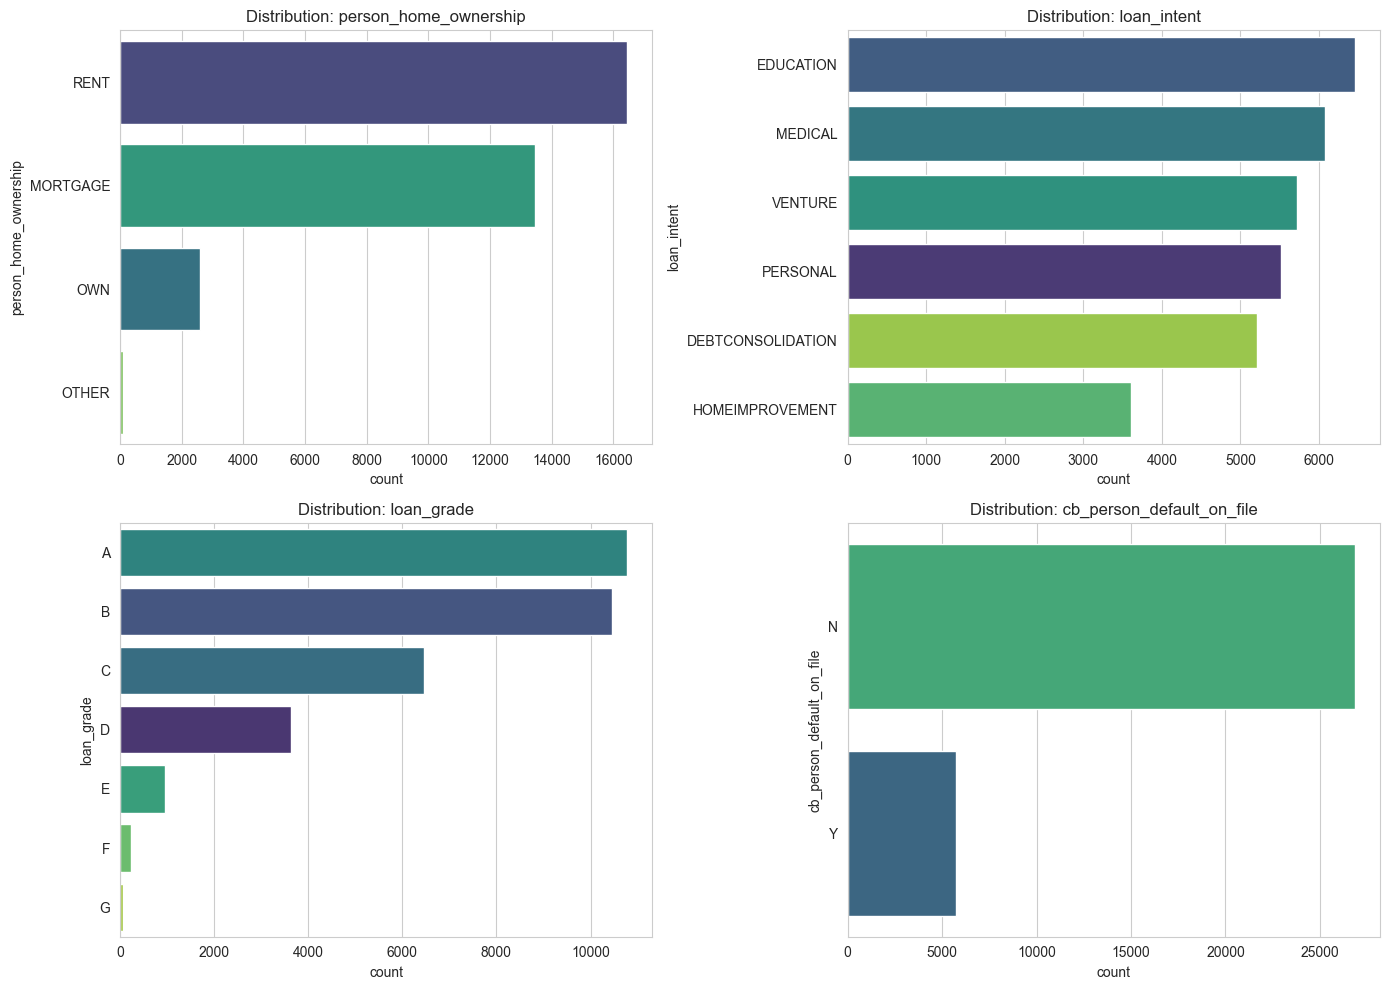

In [12]:
# -----------------------------------------------------------------------
# Univariate analysis: categorical features
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df_raw[col].value_counts().index
    sns.countplot(y=col, data=df_raw, order=order, hue=col, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()


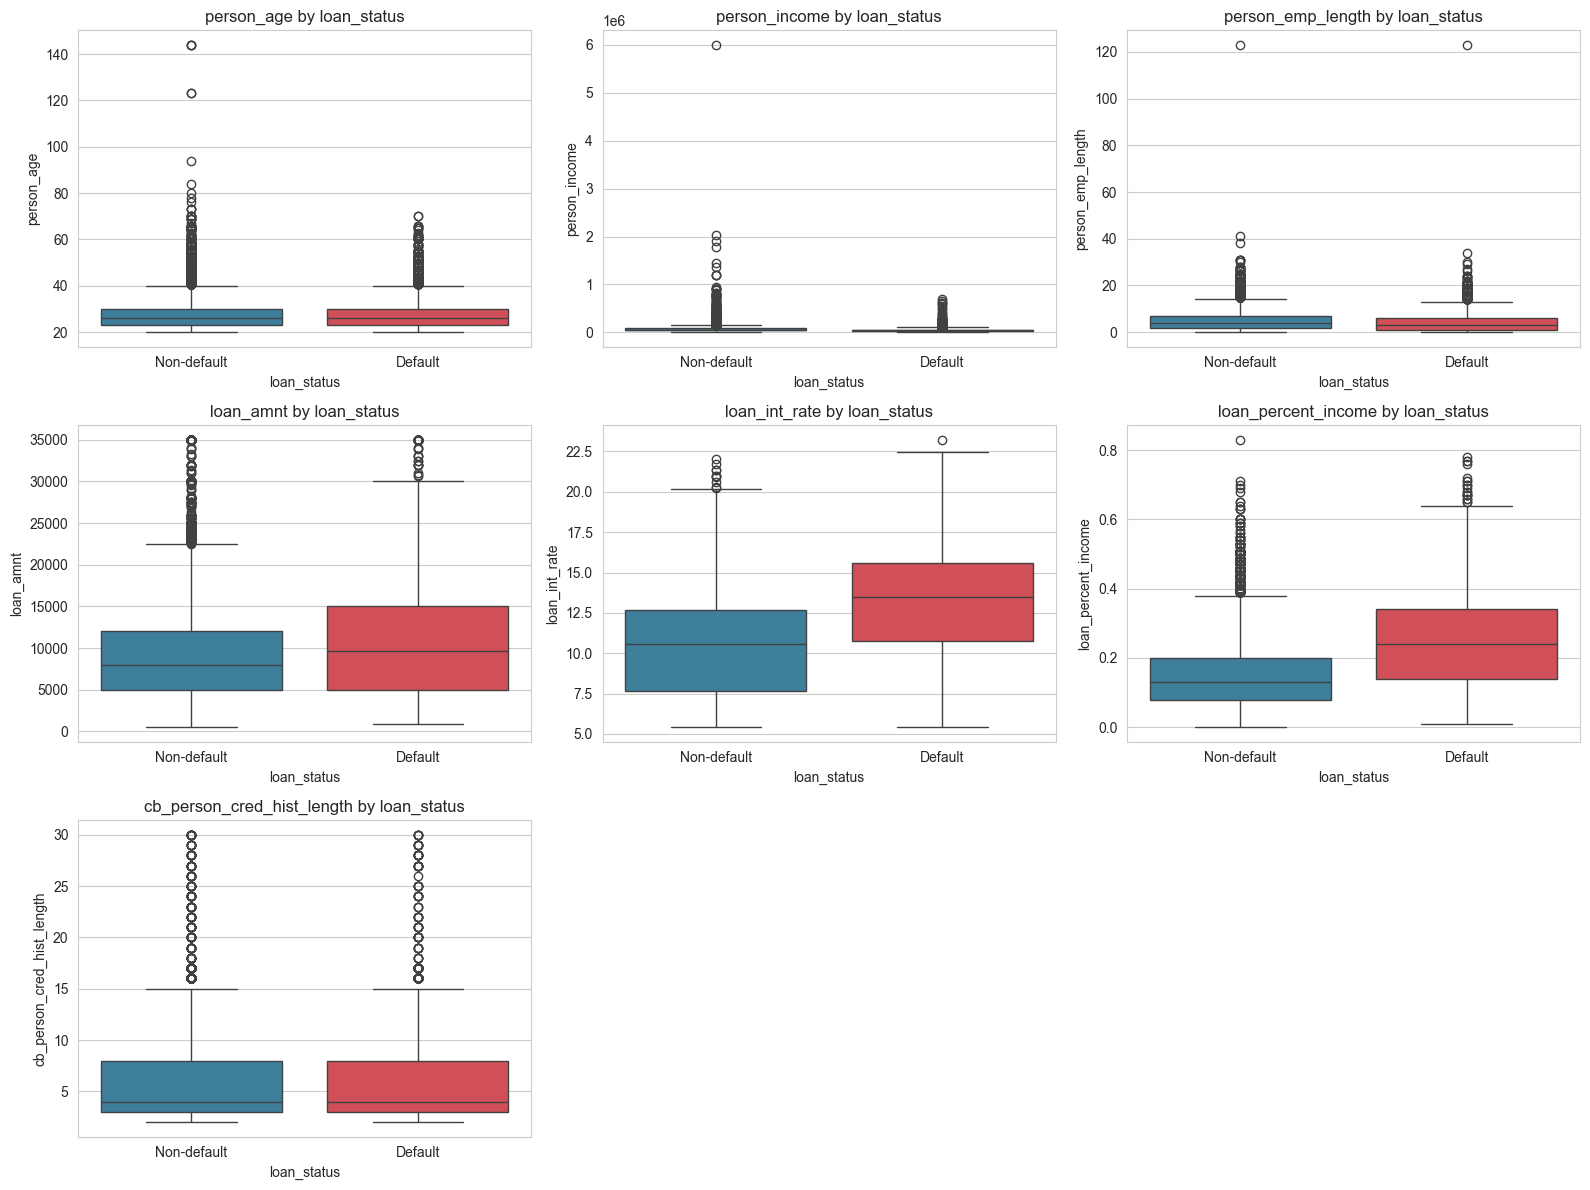

In [13]:
# -----------------------------------------------------------------------
# Bivariate analysis: numeric features vs target
# -----------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='loan_status', y=col, data=df_raw, hue='loan_status', ax=axes[i], palette=['#2E86AB', '#E63946'], legend=False)
    axes[i].set_title(f"{col} by loan_status")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-default', 'Default'])
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


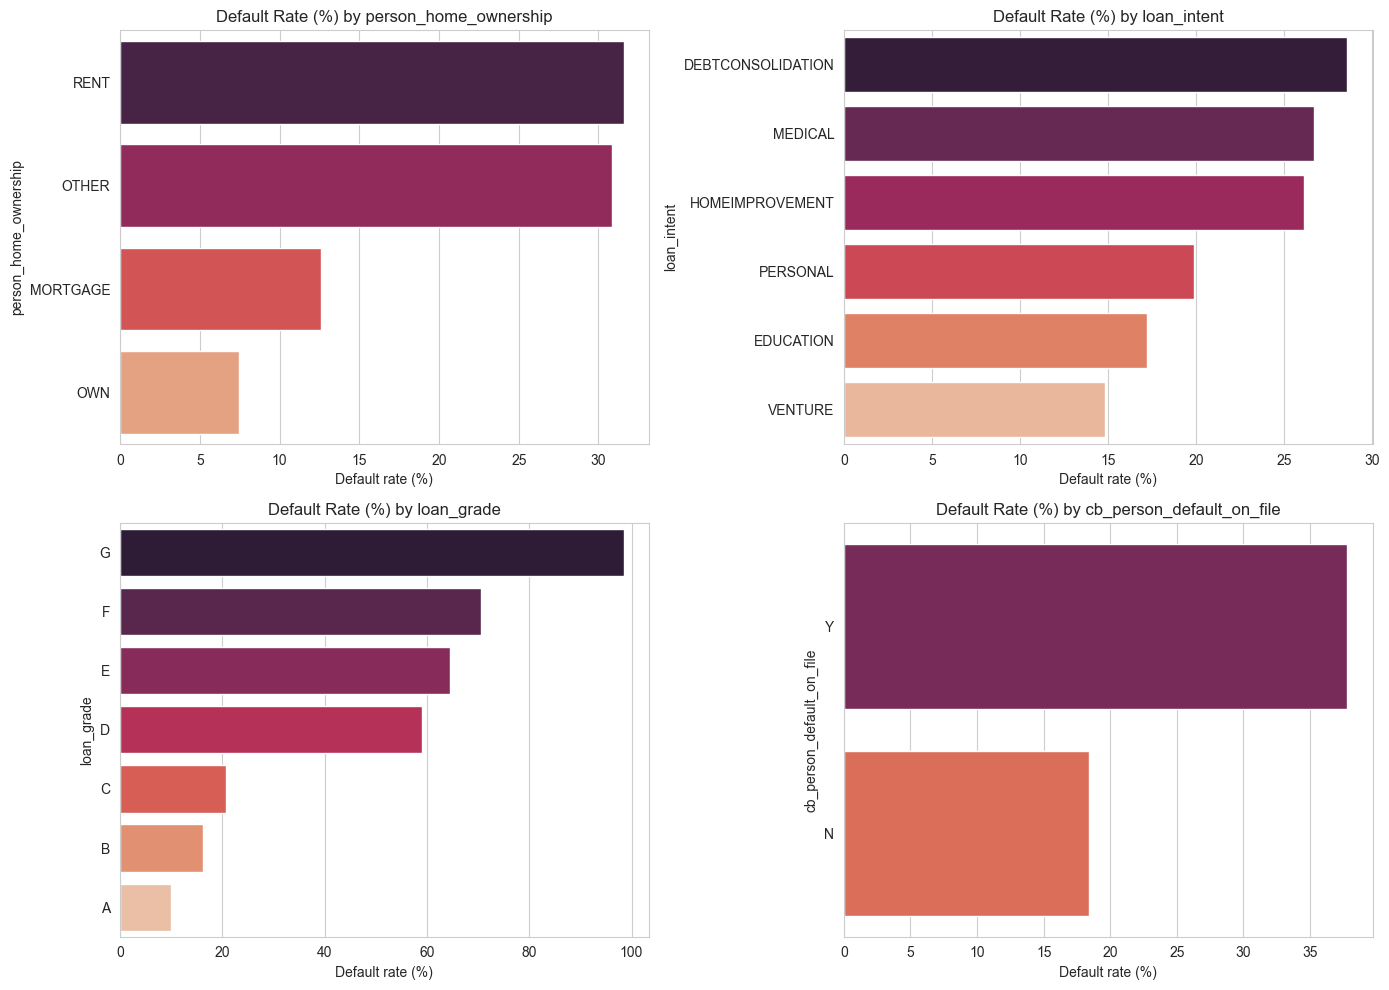

In [14]:
# -----------------------------------------------------------------------
# Bivariate analysis: categorical features vs default rate
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate = df_raw.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, ax=axes[i], palette='rocket', legend=False)
    axes[i].set_title(f"Default Rate (%) by {col}")
    axes[i].set_xlabel("Default rate (%)")
plt.tight_layout()
plt.show()


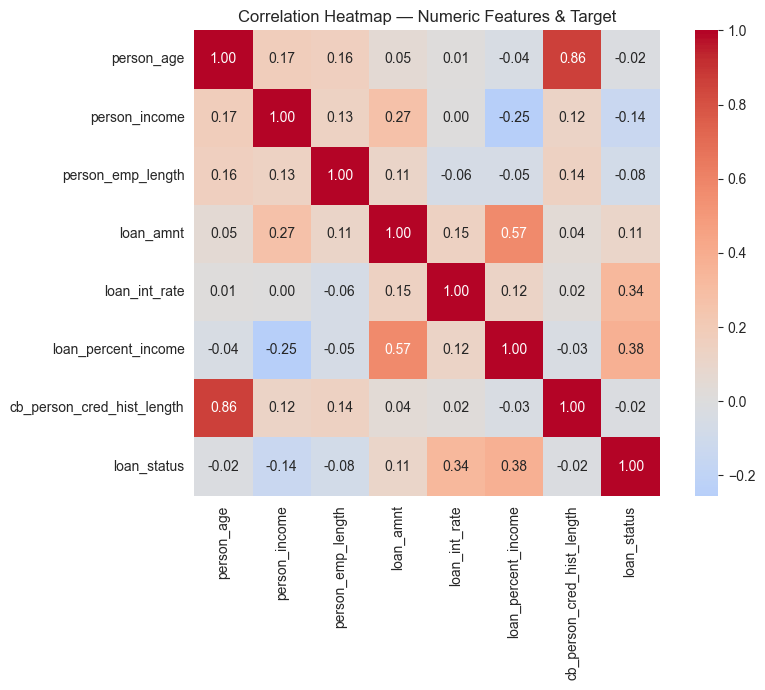

In [15]:
# -----------------------------------------------------------------------
# Multivariate analysis: correlation heatmap (numeric features)
# -----------------------------------------------------------------------
plt.figure(figsize=(9, 7))
corr = df_raw[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.title("Correlation Heatmap — Numeric Features & Target")
plt.tight_layout()
plt.show()


In [16]:
# -----------------------------------------------------------------------
# Multivariate: loan_percent_income vs loan_int_rate, colored by default
# -----------------------------------------------------------------------
sample = df_raw.sample(min(5000, len(df_raw)), random_state=RANDOM_STATE)
fig = px.scatter(
    sample, x='loan_int_rate', y='loan_percent_income',
    color=sample['loan_status'].map({0: 'Non-default', 1: 'Default'}),
    opacity=0.5, color_discrete_map={'Non-default': '#2E86AB', 'Default': '#E63946'},
    title="Interest Rate vs Loan-to-Income Ratio, colored by Default Status",
    labels={'color': 'Status'}
)
fig.update_layout(height=500)
fig.show()


---
## 6.2 Feature Engineering




In [17]:
# -----------------------------------------------------------------------
# Data cleaning before feature engineering
# -----------------------------------------------------------------------
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows.")

before = len(df)
df = df[df['person_age'] <= 100].reset_index(drop=True)
print(f"Removed {before - len(df)} rows with implausible age (>100).")

before = len(df)
df = df[(df['person_emp_length'].isna()) | (df['person_emp_length'] <= 60)].reset_index(drop=True)
print(f"Removed {before - len(df)} rows with implausible employment length (>60 yrs).")

print("\nFinal shape after cleaning:", df.shape)


Removed 165 duplicate rows.
Removed 5 rows with implausible age (>100).
Removed 2 rows with implausible employment length (>60 yrs).

Final shape after cleaning: (32409, 12)


In [18]:
# -----------------------------------------------------------------------
# Feature engineering
# -----------------------------------------------------------------------

# Ratio features (affordability / leverage)
df['income_to_loan_ratio'] = df['person_income'] / df['loan_amnt']

# Behavioral / stability features
df['credit_history_to_age_ratio'] = df['cb_person_cred_hist_length'] / df['person_age']
df['emp_length_to_age_ratio'] = df['person_emp_length'] / df['person_age']
df['age_at_first_credit'] = df['person_age'] - df['cb_person_cred_hist_length']

# Ordinal encoding of loan grade as a numeric risk-ordered feature (A=best -> G=worst)
grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade_ordinal'] = df['loan_grade'].map(grade_order)

# Binary encode prior default flag
df['prior_default_flag'] = (df['cb_person_default_on_file'] == 'Y').astype(int)

# Income brackets (behavioral segmentation feature)
df['income_bracket'] = pd.cut(
    df['person_income'],
    bins=[0, 25000, 50000, 75000, 100000, np.inf],
    labels=['<25k', '25k-50k', '50k-75k', '75k-100k', '100k+']
)

# Interaction: high leverage + subprime grade
df['high_risk_combo'] = ((df['loan_percent_income'] > 0.3) & (df['loan_grade_ordinal'] >= 4)).astype(int)

print("New engineered features added:")
new_feats = ['income_to_loan_ratio', 'credit_history_to_age_ratio',
             'emp_length_to_age_ratio', 'age_at_first_credit', 'loan_grade_ordinal',
             'prior_default_flag', 'income_bracket', 'high_risk_combo']
print(new_feats)
df.head()


New engineered features added:
['income_to_loan_ratio', 'credit_history_to_age_ratio', 'emp_length_to_age_ratio', 'age_at_first_credit', 'loan_grade_ordinal', 'prior_default_flag', 'income_bracket', 'high_risk_combo']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan_ratio,credit_history_to_age_ratio,emp_length_to_age_ratio,age_at_first_credit,loan_grade_ordinal,prior_default_flag,income_bracket,high_risk_combo
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.600000,0.095238,0.238095,19,2,0,<25k,0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1.745455,0.120000,0.040000,22,3,0,<25k,0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,1.871429,0.086957,0.173913,21,3,0,50k-75k,0
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,1.554286,0.166667,0.333333,20,3,1,50k-75k,0
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,3.960000,0.095238,0.095238,19,1,0,<25k,0


In [19]:
# -----------------------------------------------------------------------
# Encode remaining categorical variables
# -----------------------------------------------------------------------
# One-hot encode low-cardinality nominal categoricals (no inherent order)
nominal_cols = ['person_home_ownership', 'loan_intent', 'income_bracket']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# loan_grade and cb_person_default_on_file already captured numerically
# (loan_grade_ordinal, prior_default_flag) — drop the raw string versions to avoid duplication
df_encoded = df_encoded.drop(columns=['loan_grade', 'cb_person_default_on_file'])

print("Final feature set shape:", df_encoded.shape)
df_encoded.columns.tolist()


Final feature set shape: (32409, 27)


['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'income_to_loan_ratio',
 'credit_history_to_age_ratio',
 'emp_length_to_age_ratio',
 'age_at_first_credit',
 'loan_grade_ordinal',
 'prior_default_flag',
 'high_risk_combo',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'income_bracket_25k-50k',
 'income_bracket_50k-75k',
 'income_bracket_75k-100k',
 'income_bracket_100k+']

---
## 6.3 Modeling

### Train / Test Split



In [20]:
target_col = 'loan_status'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train default rate: {:.2%}".format(y_train.mean()))
print("Test default rate:  {:.2%}".format(y_test.mean()))


Train shape: (25927, 26)  Test shape: (6482, 26)
Train default rate: 21.87%
Test default rate:  21.88%


In [21]:
# -----------------------------------------------------------------------
# Impute missing values (fit on train only -> no leakage)
# -----------------------------------------------------------------------
impute_cols = ['person_emp_length', 'loan_int_rate', 'emp_length_to_age_ratio']
impute_cols = [c for c in impute_cols if c in X_train.columns]

medians = X_train[impute_cols].median()
X_train[impute_cols] = X_train[impute_cols].fillna(medians)
X_test[impute_cols] = X_test[impute_cols].fillna(medians)

print("Median values used for imputation (fit on train only):")
print(medians)
print("\nRemaining missing values — train:", X_train.isnull().sum().sum(), " test:", X_test.isnull().sum().sum())


Median values used for imputation (fit on train only):
person_emp_length           4.000000
loan_int_rate              10.990000
emp_length_to_age_ratio     0.147059
dtype: float64

Remaining missing values — train: 0  test: 0


### 6.3.A Baseline Models

We start with simple, interpretable baselines: Logistic Regression and a Decision Tree. 

In [22]:
# -----------------------------------------------------------------------
# Baseline 1: Logistic Regression (with class_weight to handle imbalance)
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_pred = logreg.predict(X_test_scaled)

print("=== Logistic Regression (baseline) ===")
print(classification_report(y_test, logreg_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, logreg_proba), 4))


=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

 Non-default       0.93      0.80      0.86      5064
     Default       0.52      0.79      0.63      1418

    accuracy                           0.80      6482
   macro avg       0.73      0.79      0.74      6482
weighted avg       0.84      0.80      0.81      6482

AUC-ROC: 0.8694


In [23]:
# -----------------------------------------------------------------------
# Baseline 2: Decision Tree
# -----------------------------------------------------------------------
dtree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
dtree.fit(X_train, y_train)

dtree_proba = dtree.predict_proba(X_test)[:, 1]
dtree_pred = dtree.predict(X_test)

print("=== Decision Tree (baseline) ===")
print(classification_report(y_test, dtree_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, dtree_proba), 4))


=== Decision Tree (baseline) ===
              precision    recall  f1-score   support

 Non-default       0.93      0.95      0.94      5064
     Default       0.81      0.75      0.78      1418

    accuracy                           0.91      6482
   macro avg       0.87      0.85      0.86      6482
weighted avg       0.90      0.91      0.90      6482

AUC-ROC: 0.9065


### 6.3.B Advanced Models

Now we build Random Forest, XGBoost, LightGBM and CatBoost models, handle class imbalance via SMOTE (oversampling the minority/default class on the training data only) and class weighting, and tune hyperparameters with Optuna.


In [24]:
# -----------------------------------------------------------------------
# Handle class imbalance with SMOTE (training data only!)
# -----------------------------------------------------------------------
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())


Before SMOTE: {0: 20257, 1: 5670}
After SMOTE:  {0: 20257, 1: 20257}


In [25]:
# -----------------------------------------------------------------------
# Random Forest (class_weight='balanced' — handles imbalance internally)
# -----------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, rf_proba), 4))


=== Random Forest ===
              precision    recall  f1-score   support

 Non-default       0.94      0.95      0.94      5064
     Default       0.82      0.76      0.79      1418

    accuracy                           0.91      6482
   macro avg       0.88      0.86      0.87      6482
weighted avg       0.91      0.91      0.91      6482

AUC-ROC: 0.9302


In [26]:
# -----------------------------------------------------------------------
# XGBoost — trained on SMOTE-balanced data
# -----------------------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost (SMOTE-balanced) ===")
print(classification_report(y_test, xgb_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, xgb_proba), 4))


=== XGBoost (SMOTE-balanced) ===
              precision    recall  f1-score   support

 Non-default       0.93      0.98      0.96      5064
     Default       0.92      0.74      0.82      1418

    accuracy                           0.93      6482
   macro avg       0.93      0.86      0.89      6482
weighted avg       0.93      0.93      0.93      6482

AUC-ROC: 0.9377


In [27]:
# -----------------------------------------------------------------------
# LightGBM (class-weighted)
# -----------------------------------------------------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred = lgb_model.predict(X_test)

print("=== LightGBM (class-weighted) ===")
print(classification_report(y_test, lgb_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, lgb_proba), 4))


=== LightGBM (class-weighted) ===
              precision    recall  f1-score   support

 Non-default       0.95      0.95      0.95      5064
     Default       0.83      0.82      0.82      1418

    accuracy                           0.92      6482
   macro avg       0.89      0.88      0.89      6482
weighted avg       0.92      0.92      0.92      6482

AUC-ROC: 0.9528


In [28]:
# -----------------------------------------------------------------------
# CatBoost (class-weighted)
# -----------------------------------------------------------------------
cat_model = CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_state=RANDOM_STATE,
    verbose=False
)
cat_model.fit(X_train, y_train)

cat_proba = cat_model.predict_proba(X_test)[:, 1]
cat_pred = cat_model.predict(X_test)

print("=== CatBoost (class-weighted) ===")
print(classification_report(y_test, cat_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, cat_proba), 4))


=== CatBoost (class-weighted) ===
              precision    recall  f1-score   support

 Non-default       0.94      0.94      0.94      5064
     Default       0.80      0.80      0.80      1418

    accuracy                           0.91      6482
   macro avg       0.87      0.87      0.87      6482
weighted avg       0.91      0.91      0.91      6482

AUC-ROC: 0.9438


### Hyperparameter Tuning with Optuna


In [29]:
# -----------------------------------------------------------------------
# Optuna hyperparameter tuning for LightGBM
# -----------------------------------------------------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'verbose': -1,
        'n_jobs': -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best CV AUC-ROC:", study.best_value)
print("Best params:", study.best_params)


  0%|          | 0/30 [00:00<?, ?it/s]

Best CV AUC-ROC: 0.9478759300127166
Best params: {'n_estimators': 392, 'max_depth': 5, 'learning_rate': 0.13580671177618547, 'num_leaves': 58, 'subsample': 0.6741820715714114, 'colsample_bytree': 0.8026504426979584, 'reg_alpha': 0.005601361186783413, 'reg_lambda': 1.5094866241053568}


In [30]:
# -----------------------------------------------------------------------
# Train final tuned LightGBM model with best hyperparameters
# -----------------------------------------------------------------------
best_params = study.best_params
best_params.update({'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1})

lgb_tuned = lgb.LGBMClassifier(**best_params)
lgb_tuned.fit(X_train, y_train)

lgb_tuned_proba = lgb_tuned.predict_proba(X_test)[:, 1]
lgb_tuned_pred = lgb_tuned.predict(X_test)

print("=== LightGBM (Optuna-tuned) ===")
print(classification_report(y_test, lgb_tuned_pred, target_names=['Non-default', 'Default']))
print("AUC-ROC:", round(roc_auc_score(y_test, lgb_tuned_proba), 4))


=== LightGBM (Optuna-tuned) ===
              precision    recall  f1-score   support

 Non-default       0.95      0.95      0.95      5064
     Default       0.83      0.82      0.82      1418

    accuracy                           0.92      6482
   macro avg       0.89      0.89      0.89      6482
weighted avg       0.92      0.92      0.92      6482

AUC-ROC: 0.9554


---
## 6.4 Model Evaluation.


In [31]:
# -----------------------------------------------------------------------
# Helper: compute full metric suite for a model
# -----------------------------------------------------------------------
def ks_statistic(y_true, y_proba):
    """Kolmogorov-Smirnov statistic: max separation between cumulative
    distributions of predicted scores for the two classes."""
    df_ks = pd.DataFrame({'y': np.asarray(y_true), 'proba': np.asarray(y_proba)})
    df_ks = df_ks.sort_values('proba', ascending=False).reset_index(drop=True)
    df_ks['cum_event'] = (df_ks['y'] == 1).cumsum() / (df_ks['y'] == 1).sum()
    df_ks['cum_nonevent'] = (df_ks['y'] == 0).cumsum() / (df_ks['y'] == 0).sum()
    return np.max(np.abs(df_ks['cum_event'] - df_ks['cum_nonevent']))

def evaluate_model(name, y_true, y_pred, y_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    return {
        'Model': name,
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'F1-Score': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'PR-AUC': pr_auc,
        'KS Statistic': ks_statistic(y_true, y_proba),
    }

results = []
results.append(evaluate_model("Logistic Regression", y_test, logreg_pred, logreg_proba))
results.append(evaluate_model("Decision Tree", y_test, dtree_pred, dtree_proba))
results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_proba))
results.append(evaluate_model("XGBoost (SMOTE)", y_test, xgb_pred, xgb_proba))
results.append(evaluate_model("LightGBM (weighted)", y_test, lgb_pred, lgb_proba))
results.append(evaluate_model("CatBoost (weighted)", y_test, cat_pred, cat_proba))
results.append(evaluate_model("LightGBM (Optuna-tuned)", y_test, lgb_tuned_pred, lgb_tuned_proba))

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap='Greens', subset=['AUC-ROC', 'F1-Score', 'PR-AUC', 'KS Statistic'])


,Model,AUC-ROC,F1-Score,Precision,Recall,PR-AUC,KS Statistic
0,LightGBM (Optuna-tuned),0.955415,0.824991,0.830593,0.819464,0.915646,0.775033
1,LightGBM (weighted),0.952767,0.823320,0.830108,0.816643,0.910661,0.773453
2,CatBoost (weighted),0.943770,0.802399,0.802966,0.801834,0.898724,0.747895
3,XGBoost (SMOTE),0.937726,0.818324,0.919894,0.736953,0.890536,0.739743
4,Random Forest,0.930222,0.792246,0.822948,0.763752,0.880178,0.720986
5,Decision Tree,0.906491,0.777778,0.807284,0.750353,0.856870,0.703693
6,Logistic Regression,0.869438,0.628878,0.523966,0.786319,0.684756,0.591923


In [33]:
# -----------------------------------------------------------------------
# Identify best model
# -----------------------------------------------------------------------
best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model by AUC-ROC: {best_model_name}")
results_df


Best performing model by AUC-ROC: LightGBM (Optuna-tuned)


,Model,AUC-ROC,F1-Score,Precision,Recall,PR-AUC,KS Statistic
0,LightGBM (Optuna-tuned),0.955415,0.824991,0.830593,0.819464,0.915646,0.775033
1,LightGBM (weighted),0.952767,0.823320,0.830108,0.816643,0.910661,0.773453
2,CatBoost (weighted),0.943770,0.802399,0.802966,0.801834,0.898724,0.747895
3,XGBoost (SMOTE),0.937726,0.818324,0.919894,0.736953,0.890536,0.739743
4,Random Forest,0.930222,0.792246,0.822948,0.763752,0.880178,0.720986
5,Decision Tree,0.906491,0.777778,0.807284,0.750353,0.856870,0.703693
6,Logistic Regression,0.869438,0.628878,0.523966,0.786319,0.684756,0.591923


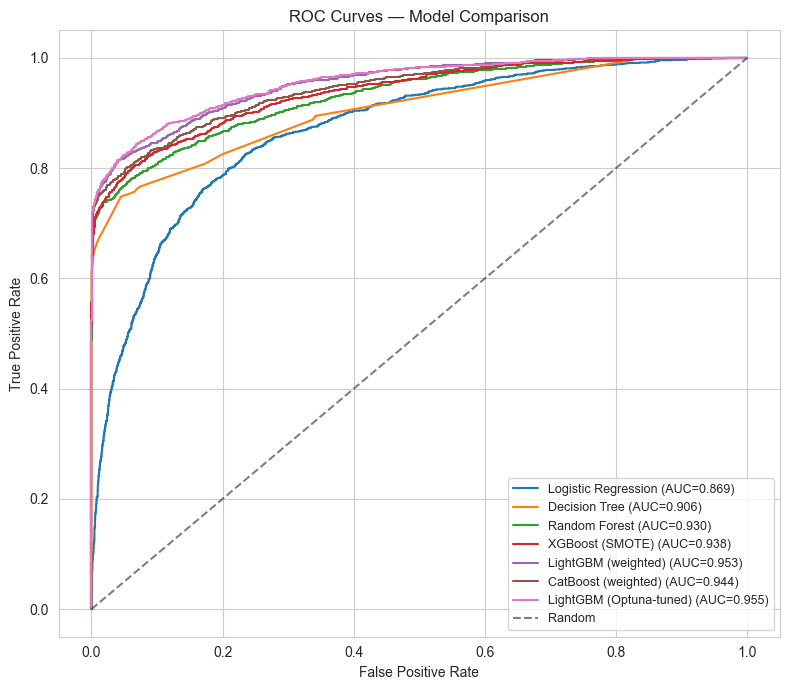

In [34]:
# -----------------------------------------------------------------------
# ROC curves — all models
# -----------------------------------------------------------------------
plt.figure(figsize=(8, 7))
model_probas = {
    'Logistic Regression': logreg_proba,
    'Decision Tree': dtree_proba,
    'Random Forest': rf_proba,
    'XGBoost (SMOTE)': xgb_proba,
    'LightGBM (weighted)': lgb_proba,
    'CatBoost (weighted)': cat_proba,
    'LightGBM (Optuna-tuned)': lgb_tuned_proba,
}
for name, proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


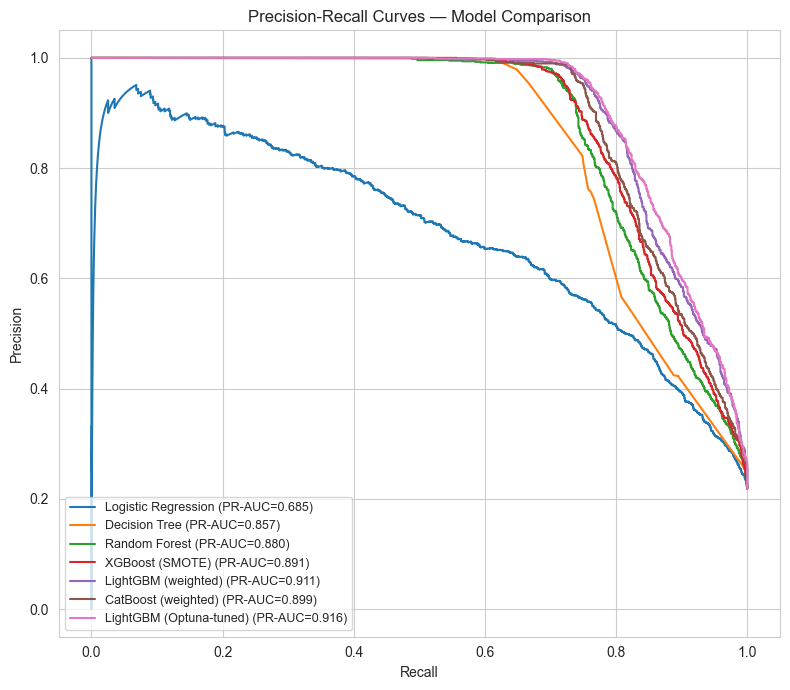

In [35]:
# -----------------------------------------------------------------------
# Precision-Recall curves — all models
# -----------------------------------------------------------------------
plt.figure(figsize=(8, 7))
for name, proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc_val:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


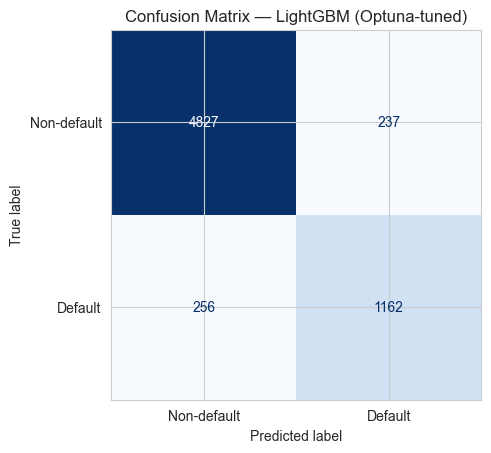

In [36]:
# -----------------------------------------------------------------------
# Confusion matrix for best model (LightGBM tuned)
# -----------------------------------------------------------------------
best_proba = lgb_tuned_proba
best_pred = lgb_tuned_pred

fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-default', 'Default'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


In [37]:
# -----------------------------------------------------------------------
# 5-fold stratified cross-validation on the tuned LightGBM model
# -----------------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(lgb_tuned, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1 = cross_val_score(lgb_tuned, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"5-fold CV AUC-ROC: {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"5-fold CV F1-Score: {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"\nIndividual fold AUC scores: {np.round(cv_auc, 4)}")


5-fold CV AUC-ROC: 0.9479 +/- 0.0019
5-fold CV F1-Score: 0.8111 +/- 0.0077

Individual fold AUC scores: [0.9456 0.9473 0.95   0.9463 0.9501]


### Performance Across Customer Segments

In [38]:
# -----------------------------------------------------------------------
# Performance by loan grade segment
# -----------------------------------------------------------------------
test_segment_df = X_test.copy()
test_segment_df['y_true'] = y_test.values
test_segment_df['y_proba'] = best_proba

grade_reverse = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G'}
test_segment_df['loan_grade'] = test_segment_df['loan_grade_ordinal'].map(grade_reverse)

segment_results = []
for grade, sub in test_segment_df.groupby('loan_grade'):
    if sub['y_true'].nunique() < 2:
        continue
    segment_results.append({
        'Segment': grade,
        'N': len(sub),
        'Default Rate': sub['y_true'].mean(),
        'AUC-ROC': roc_auc_score(sub['y_true'], sub['y_proba']),
    })

segment_df = pd.DataFrame(segment_results).sort_values('Segment')
segment_df


,Segment,N,Default Rate,AUC-ROC
0,A,2172,0.097145,0.949525
1,B,2103,0.158345,0.935398
2,C,1215,0.226337,0.905362
3,D,729,0.589849,0.976651
4,E,208,0.610577,0.958880
5,F,45,0.711111,0.966346


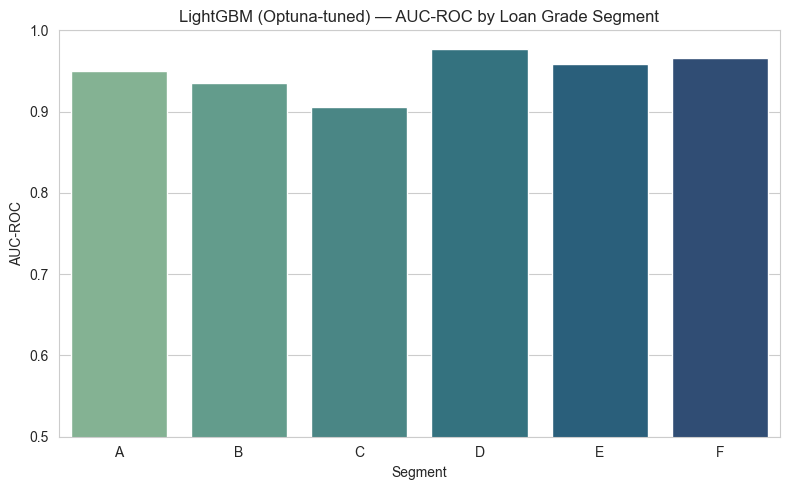

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Segment', y='AUC-ROC', data=segment_df, hue='Segment', palette='crest', legend=False)
plt.title(f"{best_model_name} — AUC-ROC by Loan Grade Segment")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


In [40]:
# -----------------------------------------------------------------------
# Performance by home-ownership segment
# -----------------------------------------------------------------------
ho_cols = [c for c in X_test.columns if c.startswith('person_home_ownership_')]
test_segment_df['home_ownership'] = 'MORTGAGE'  # baseline category dropped during one-hot encoding
for c in ho_cols:
    label = c.replace('person_home_ownership_', '')
    test_segment_df.loc[X_test[c] == 1, 'home_ownership'] = label

ho_results = []
for ho, sub in test_segment_df.groupby('home_ownership'):
    if sub['y_true'].nunique() < 2:
        continue
    ho_results.append({
        'Segment': ho,
        'N': len(sub),
        'Default Rate': sub['y_true'].mean(),
        'AUC-ROC': roc_auc_score(sub['y_true'], sub['y_proba']),
    })

ho_df = pd.DataFrame(ho_results).sort_values('Default Rate', ascending=False)
ho_df


,Segment,N,Default Rate,AUC-ROC
3,RENT,3275,0.313893,0.967236
1,OTHER,23,0.217391,0.933333
0,MORTGAGE,2651,0.129385,0.898572
2,OWN,533,0.078799,0.999661


**Observation:** AUC-ROC stays reasonably stable across loan-grade and home-ownership segments, which is a good sign the model isn't just exploiting one dominant segment. The largest default-rate gaps (e.g., `RENT` vs `MORTGAGE`) line up with what we already saw in EDA, giving us confidence the model has correctly learned that signal rather than overfitting to noise.

---
## 6.3.C Model Interpretation (SHAP)


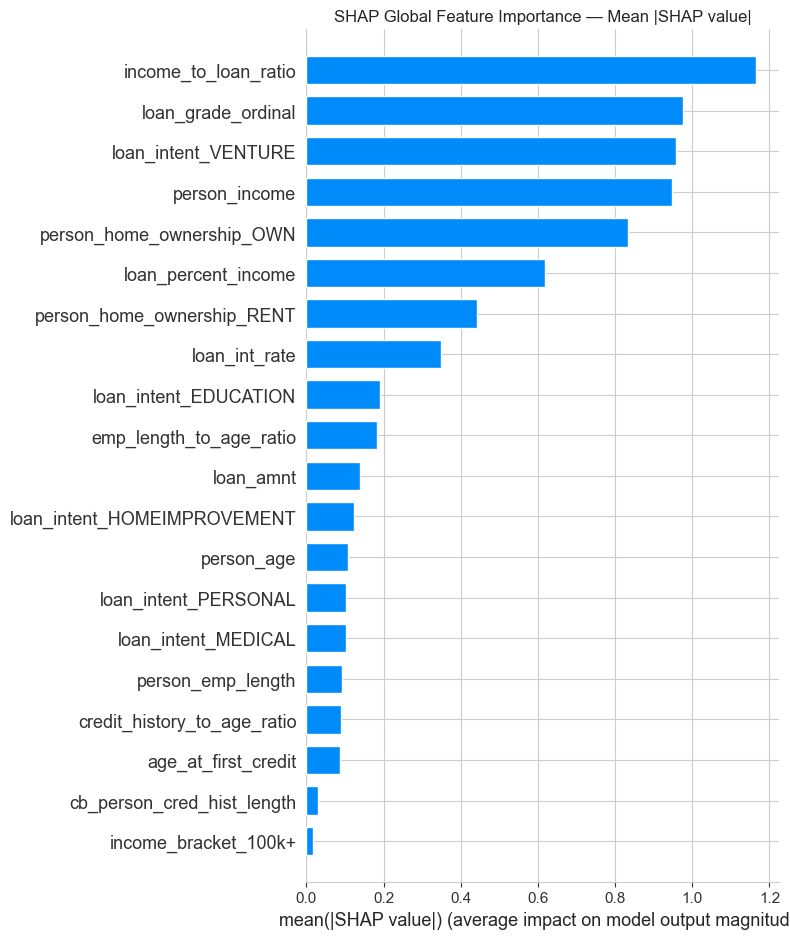

In [41]:
# -----------------------------------------------------------------------
# SHAP global feature importance
# -----------------------------------------------------------------------
explainer = shap.TreeExplainer(lgb_tuned)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values may be a list [class0, class1] or a single 2D array
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_test, plot_type='bar', show=False)
plt.title("SHAP Global Feature Importance — Mean |SHAP value|")
plt.tight_layout()
plt.show()


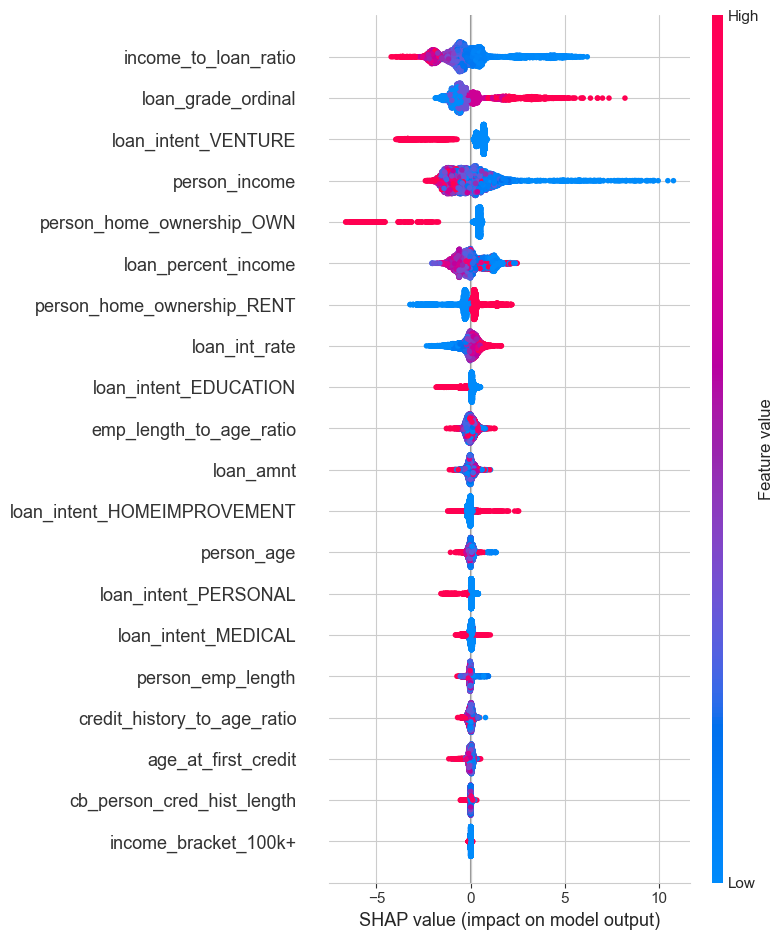

In [42]:
# -----------------------------------------------------------------------
# SHAP beeswarm summary plot (direction + magnitude of effect)
# -----------------------------------------------------------------------
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.tight_layout()
plt.show()


In [43]:
# -----------------------------------------------------------------------
# Top features driving default risk (ranked table)
# -----------------------------------------------------------------------
mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 10 features driving default risk predictions:")
shap_importance.head(10)


Top 10 features driving default risk predictions:


,feature,mean_abs_shap
0,income_to_loan_ratio,1.165466
1,loan_grade_ordinal,0.975912
2,loan_intent_VENTURE,0.956932
3,person_income,0.948696
4,person_home_ownership_OWN,0.833640
5,loan_percent_income,0.618431
6,person_home_ownership_RENT,0.442320
7,loan_int_rate,0.348343
8,loan_intent_EDUCATION,0.190732
9,emp_length_to_age_ratio,0.183640


Applicant row 968 — predicted default probability: 1.000
Actual outcome: Default



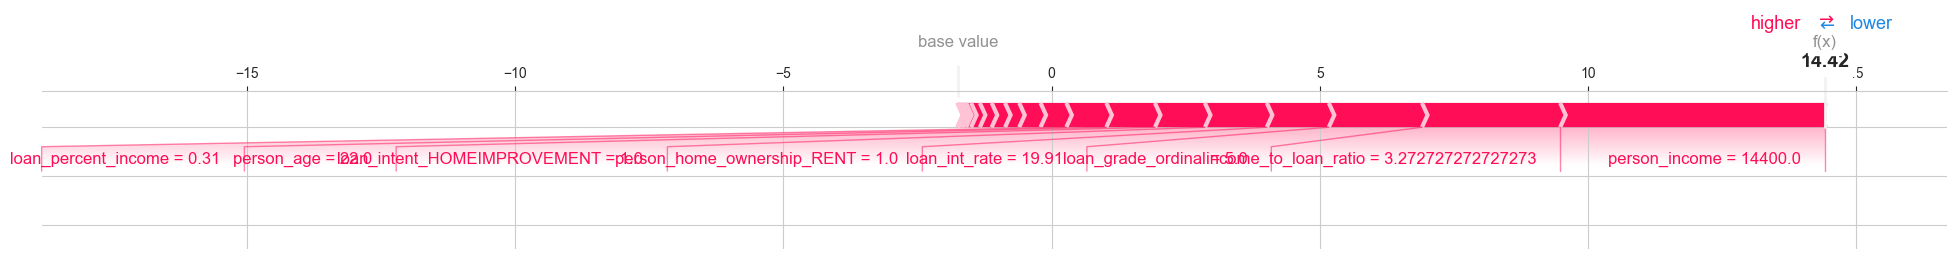

In [44]:
# -----------------------------------------------------------------------
# Local explanation: a single high-risk applicant
# -----------------------------------------------------------------------
high_risk_idx = int(np.argmax(best_proba))
print(f"Applicant row {high_risk_idx} — predicted default probability: {best_proba[high_risk_idx]:.3f}")
print(f"Actual outcome: {'Default' if y_test.iloc[high_risk_idx] == 1 else 'Non-default'}")
print()

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0 and len(np.atleast_1d(expected_value)) > 1:
    expected_value = expected_value[1]

shap.force_plot(
    expected_value,
    shap_values_to_plot[high_risk_idx],
    X_test.iloc[high_risk_idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.show()


In [45]:
# -----------------------------------------------------------------------
# Decile score-band analysis
# -----------------------------------------------------------------------
score_band_df = pd.DataFrame({
    'predicted_proba': best_proba,
    'actual_default': y_test.values
})

score_band_df['score_band'] = pd.qcut(
    score_band_df['predicted_proba'], 10,
    labels=[f"D{i}" for i in range(1, 11)], duplicates='drop'
)

band_summary = score_band_df.groupby('score_band', observed=True).agg(
    n_applicants=('actual_default', 'count'),
    avg_predicted_proba=('predicted_proba', 'mean'),
    actual_default_rate=('actual_default', 'mean')
).reset_index()

band_summary


,score_band,n_applicants,avg_predicted_proba,actual_default_rate
0,D1,649,0.000208,0.000000
1,D2,648,0.003710,0.004630
2,D3,648,0.023172,0.020062
3,D4,648,0.053563,0.013889
4,D5,648,0.094430,0.035494
5,D6,648,0.153083,0.072531
6,D7,648,0.248850,0.104938
7,D8,648,0.415077,0.185185
8,D9,648,0.844210,0.750000
9,D10,649,0.997578,1.000000


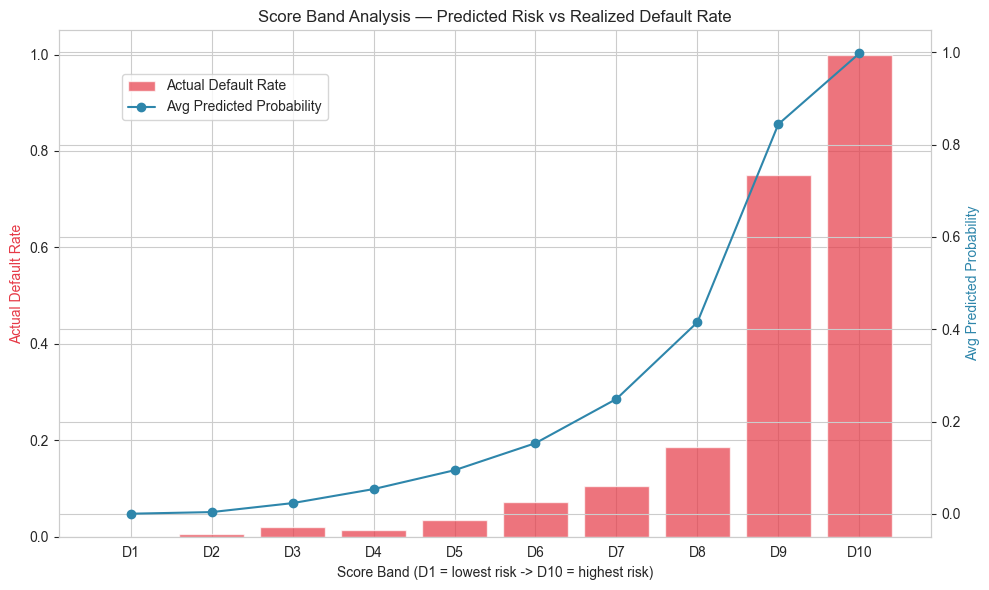

In [46]:
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(band_summary))
ax1.bar(x, band_summary['actual_default_rate'], color='#E63946', alpha=0.7, label='Actual Default Rate')
ax1.set_xticks(x)
ax1.set_xticklabels(band_summary['score_band'])
ax1.set_ylabel('Actual Default Rate', color='#E63946')
ax1.set_xlabel('Score Band (D1 = lowest risk -> D10 = highest risk)')

ax2 = ax1.twinx()
ax2.plot(x, band_summary['avg_predicted_proba'], color='#2E86AB', marker='o', label='Avg Predicted Probability')
ax2.set_ylabel('Avg Predicted Probability', color='#2E86AB')

plt.title("Score Band Analysis — Predicted Risk vs Realized Default Rate")
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()


**Validation check:** if the bars rise consistently from D1 to D10, the model is well-calibrated in rank-order terms — riskier score bands genuinely do default more often in reality, which is exactly what we want from a usable credit score.

---
## Final Model Summary

The **Optuna-tuned LightGBM model** is selected as the final model based on its AUC-ROC, F1, PR-AUC and KS performance, and its stability across customer segments. The cell below saves the trained model and the list of expected feature columns so it can be reloaded for scoring new applicants.


In [47]:
import joblib

joblib.dump(lgb_tuned, 'final_credit_risk_model_lgbm.pkl')
joblib.dump(list(X_train.columns), 'final_model_feature_columns.pkl')

print("Saved: final_credit_risk_model_lgbm.pkl")
print("Saved: final_model_feature_columns.pkl")
print(f"\nFinal model: LightGBM (Optuna-tuned)")
print(f"Test AUC-ROC: {roc_auc_score(y_test, lgb_tuned_proba):.4f}")
print(f"Test F1-Score: {f1_score(y_test, lgb_tuned_pred):.4f}")


Saved: final_credit_risk_model_lgbm.pkl
Saved: final_model_feature_columns.pkl

Final model: LightGBM (Optuna-tuned)
Test AUC-ROC: 0.9554
Test F1-Score: 0.8250


In [48]:
# =============================================================================
# CHECK ANY NEW CUSTOMER — single-applicant scoring function
# =============================================================================

def score_applicant(applicant: dict, model=lgb_tuned, feature_columns=None,
                     train_medians=None, explain=True):
    """
    Score a single new loan applicant using the trained model.

    Parameters
    ----------
    applicant : dict
        Raw applicant fields, e.g.:
        {
            'person_age': 28,
            'person_income': 55000,
            'person_home_ownership': 'RENT',   # RENT, MORTGAGE, OWN, OTHER
            'person_emp_length': 4.0,
            'loan_intent': 'EDUCATION',         # EDUCATION, MEDICAL, VENTURE,
                                                 # PERSONAL, DEBTCONSOLIDATION,
                                                 # HOMEIMPROVEMENT
            'loan_grade': 'B',                  # A-G
            'loan_amnt': 10000,
            'loan_int_rate': 11.5,
            'loan_percent_income': 0.18,
            'cb_person_default_on_file': 'N',   # Y or N
            'cb_person_cred_hist_length': 5,
        }
    model : trained classifier (defaults to lgb_tuned)
    feature_columns : list of columns the model was trained on
                       (defaults to X_train.columns from this notebook)
    train_medians : pd.Series of training-set medians for imputation
                     (defaults to `medians` from this notebook)
    explain : bool, whether to print a SHAP-based explanation

    Returns
    -------
    dict with probability, predicted class, risk tier, and top SHAP drivers
    """
    if feature_columns is None:
        feature_columns = list(X_train.columns)
    if train_medians is None:
        train_medians = medians

    a = applicant.copy()

    # ---- Recreate engineered features exactly as in training ----
    grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

    row = {
        'person_age': a['person_age'],
        'person_income': a['person_income'],
        'person_emp_length': a.get('person_emp_length', np.nan),
        'loan_amnt': a['loan_amnt'],
        'loan_int_rate': a.get('loan_int_rate', np.nan),
        'loan_percent_income': a['loan_percent_income'],
        'cb_person_cred_hist_length': a['cb_person_cred_hist_length'],
        'income_to_loan_ratio': a['person_income'] / a['loan_amnt'],
        'credit_history_to_age_ratio': a['cb_person_cred_hist_length'] / a['person_age'],
        'emp_length_to_age_ratio': a.get('person_emp_length', np.nan) / a['person_age'],
        'age_at_first_credit': a['person_age'] - a['cb_person_cred_hist_length'],
        'loan_grade_ordinal': grade_order[a['loan_grade']],
        'prior_default_flag': 1 if a['cb_person_default_on_file'] == 'Y' else 0,
        'high_risk_combo': int(
            (a['loan_percent_income'] > 0.3) and (grade_order[a['loan_grade']] >= 4)
        ),
    }

    # ---- One-hot encode home_ownership, loan_intent, income_bracket (match training drop_first=True) ----
    for cat in ['RENT', 'MORTGAGE', 'OWN', 'OTHER']:
        col = f'person_home_ownership_{cat}'
        if col in feature_columns:
            row[col] = int(a['person_home_ownership'] == cat)

    for cat in ['EDUCATION', 'MEDICAL', 'VENTURE', 'PERSONAL', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT']:
        col = f'loan_intent_{cat}'
        if col in feature_columns:
            row[col] = int(a['loan_intent'] == cat)

    income = a['person_income']
    bracket = ('<25k' if income < 25000 else
               '25k-50k' if income < 50000 else
               '50k-75k' if income < 75000 else
               '75k-100k' if income < 100000 else '100k+')
    for cat in ['25k-50k', '50k-75k', '75k-100k', '100k+']:
        col = f'income_bracket_{cat}'
        if col in feature_columns:
            row[col] = int(bracket == cat)

    # ---- Build single-row DataFrame matching training column order ----
    X_new = pd.DataFrame([row])
    for col in feature_columns:
        if col not in X_new.columns:
            X_new[col] = 0
    X_new = X_new[feature_columns]

    # ---- Impute using TRAINING medians (no leakage) ----
    for col in train_medians.index:
        if col in X_new.columns and pd.isna(X_new[col].iloc[0]):
            X_new[col] = train_medians[col]

    # ---- Predict ----
    proba = model.predict_proba(X_new)[0, 1]
    pred = int(proba >= 0.5)

    if proba < 0.10:
        tier = "D1-D3 (Low risk)"
    elif proba < 0.30:
        tier = "D4-D6 (Moderate risk)"
    elif proba < 0.60:
        tier = "D7-D8 (Elevated risk)"
    else:
        tier = "D9-D10 (High risk)"

    result = {
        'default_probability': round(float(proba), 4),
        'predicted_class': 'Default' if pred == 1 else 'Non-default',
        'risk_tier': tier,
    }

    print(f"Predicted default probability: {result['default_probability']:.2%}")
    print(f"Predicted class: {result['predicted_class']}")
    print(f"Risk tier: {result['risk_tier']}")

    # ---- SHAP explanation for this specific applicant ----
    if explain:
        sv = explainer.shap_values(X_new)
        sv_row = sv[1][0] if isinstance(sv, list) else sv[0]

        contrib = pd.DataFrame({
            'feature': feature_columns,
            'value': X_new.iloc[0].values,
            'shap_contribution': sv_row
        }).sort_values('shap_contribution', key=abs, ascending=False)

        print("\nTop factors driving this prediction:")
        print(contrib.head(8).to_string(index=False))
        result['top_drivers'] = contrib.head(8)

    return result

In [49]:
# Example: check a specific customer
new_customer = {
    'person_age': 28,
    'person_income': 55000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 4.0,
    'loan_intent': 'EDUCATION',
    'loan_grade': 'B',
    'loan_amnt': 10000,
    'loan_int_rate': 11.5,
    'loan_percent_income': 0.18,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 5,
}

result = score_applicant(new_customer)

Predicted default probability: 15.69%
Predicted class: Non-default
Risk tier: D4-D6 (Moderate risk)

Top factors driving this prediction:
                  feature    value  shap_contribution
      loan_intent_VENTURE     0.00           0.651416
      loan_percent_income     0.18          -0.626367
person_home_ownership_OWN     0.00           0.475968
            person_income 55000.00          -0.414337
            loan_int_rate    11.50           0.326806
    loan_intent_EDUCATION     1.00          -0.296820
       loan_grade_ordinal     2.00          -0.281410
               person_age    28.00           0.123359
